# Exploratory Data Analysis (EDA): BiRefNet Segmentation Performance Analysis

### Overview
This notebook evaluates the background matting and object segmentation capabilities of BiRefNet within the wildlife monitoring pipeline. Following presentation feedback, this analysis highlights both the structural strengths and visual failure modes of the model when processing raw trail-camera footage.

### Pipeline Framework
This notebook evaluates five distinct case studies categorized across:
* **Successful Extractions:** Baseline performance, extreme lighting/low-contrast resilience, and scale variance.
* **Failure Modes:** Severe cross-cutting environmental occlusions and multi-target spatial overlapping.

#### Imports and Global Configurations

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

from metadata import CASE_STUDIES # Case studies metadata

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

#### Core Plotting Engine

In [3]:
def plot_case_study(study_dict):
    """
    Loads and displays side-by-side comparisons of raw inputs and segmented outputs.
    """
    raw_path = study_dict["raw"]
    mask_path = study_dict["mask"]
    
    # Verification check for file existence
    if not os.path.exists(raw_path) or not os.path.exists(mask_path):

        print(f"[Warning] Skipping: '{study_dict['title']}'. Verification assets missing.")
        return


    # Read and convert color spaces from BGR to RGB
    raw_img = cv2.cvtColor(cv2.imread(raw_path), cv2.COLOR_BGR2RGB)
    mask_img = cv2.cvtColor(cv2.imread(mask_path), cv2.COLOR_BGR2RGB)

    # Initialize subplots
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    # Display Raw Image
    axs[0].imshow(raw_img)
    axs[0].set_title("Before: Raw Frame Input", fontsize=12, fontweight='bold', pad=10)
    axs[0].axis('off')

    # Display Segmented Result
    axs[1].imshow(mask_img)
    axs[1].set_title("After: BiRefNet Segmentation Output", fontsize=12, fontweight='bold', pad=10)
    axs[1].axis('off')

    # Global titles and annotations
    plt.suptitle(study_dict["title"], fontsize=15, fontweight='bold', y=0.98)
    
    # Subtext styling matching performance type
    color_map = {"Success": "#27ae60", "Failure": "#c0392b"}
    status_color = color_map.get(study_dict["type"], "#333333")
    
    fig.text(0.5, 0.02, f"Analysis Focus: {study_dict['desc']}", 
             ha='center', fontsize=11, style='italic', color=status_color, wrap=True)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

## Section 1: Pipeline Structural Strengths (Successful Extractions)
This section displays scenarios where the deep-attention mechanisms of BiRefNet cleanly isolate canine boundaries from complicated wilderness backgrounds.

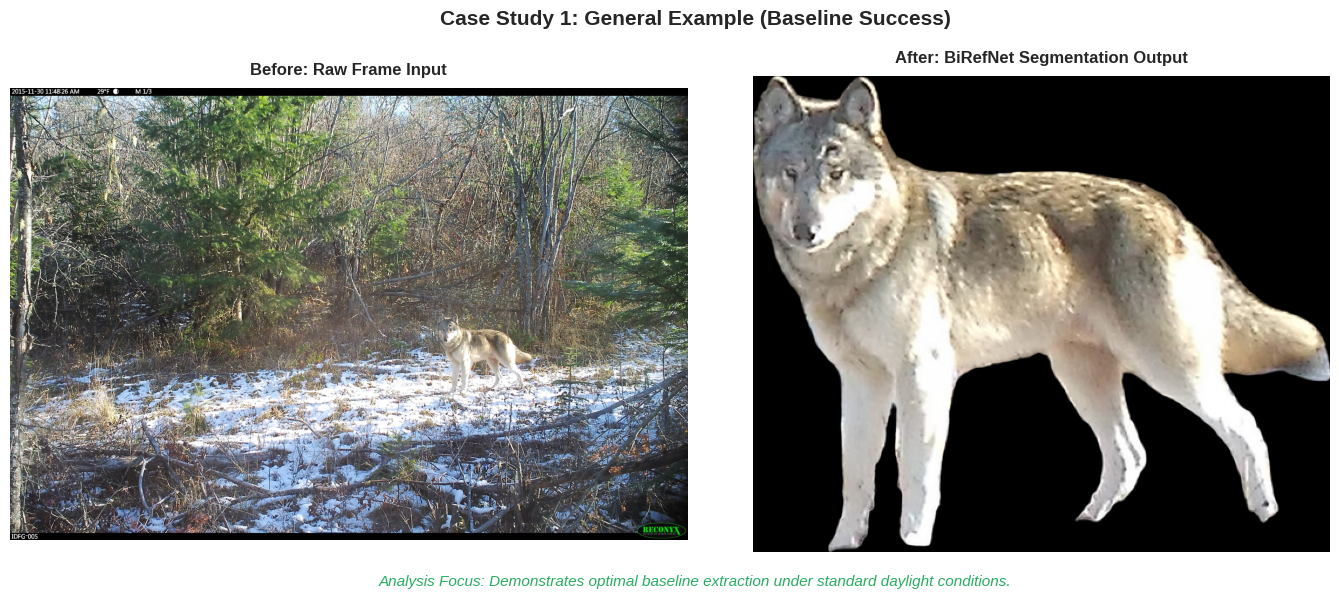

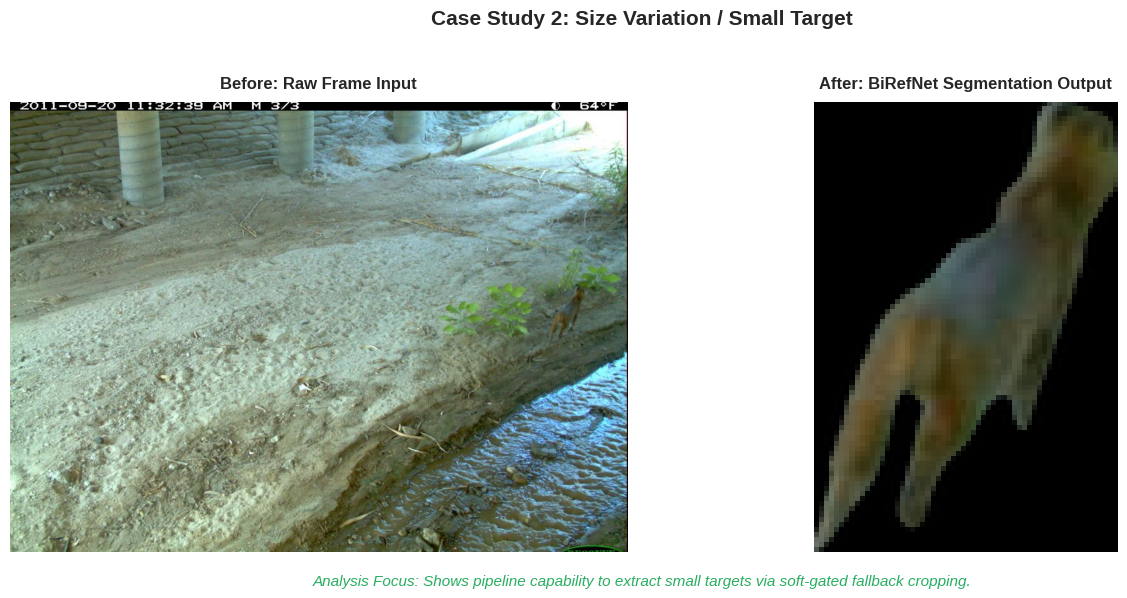

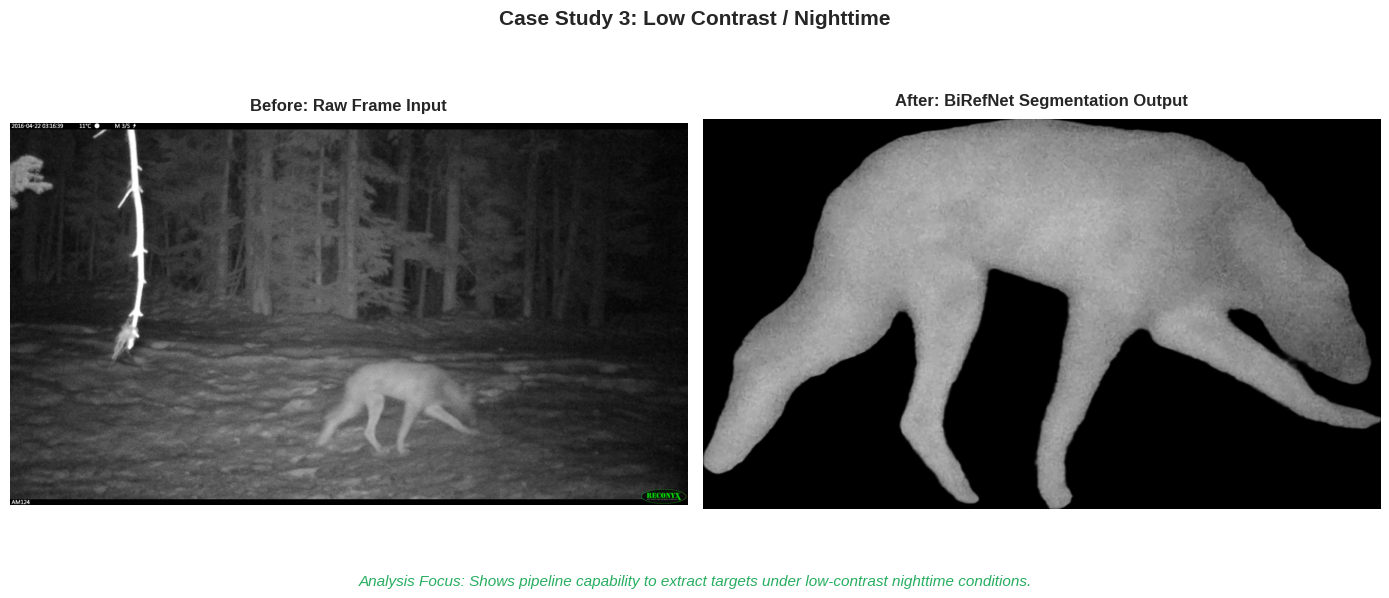

In [4]:
# Filter and execute success evaluation cases
for study in CASE_STUDIES:

    if study["type"] == "Success":

        plot_case_study(study)
        

## Section 2: Pipeline Structural Weaknesses (Edge Cases & Limitations)
This section exposes the upper boundaries of our matting performance, analyzing edge erosion, mask fragmentation, and instance merging.

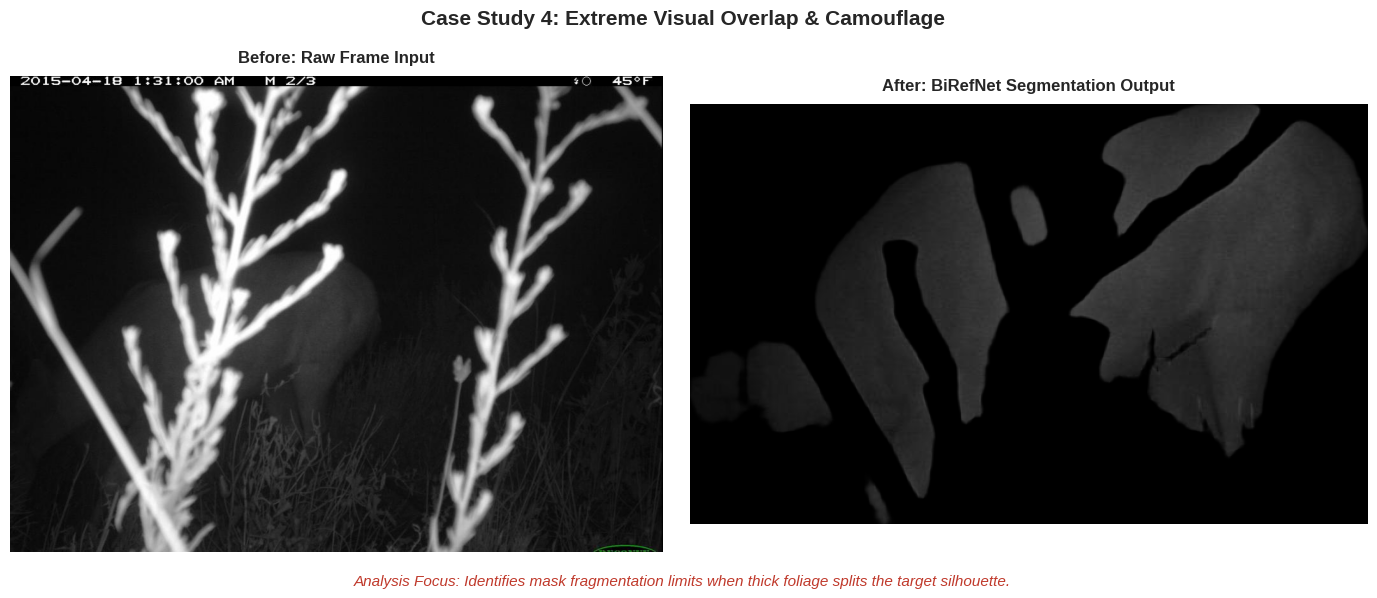

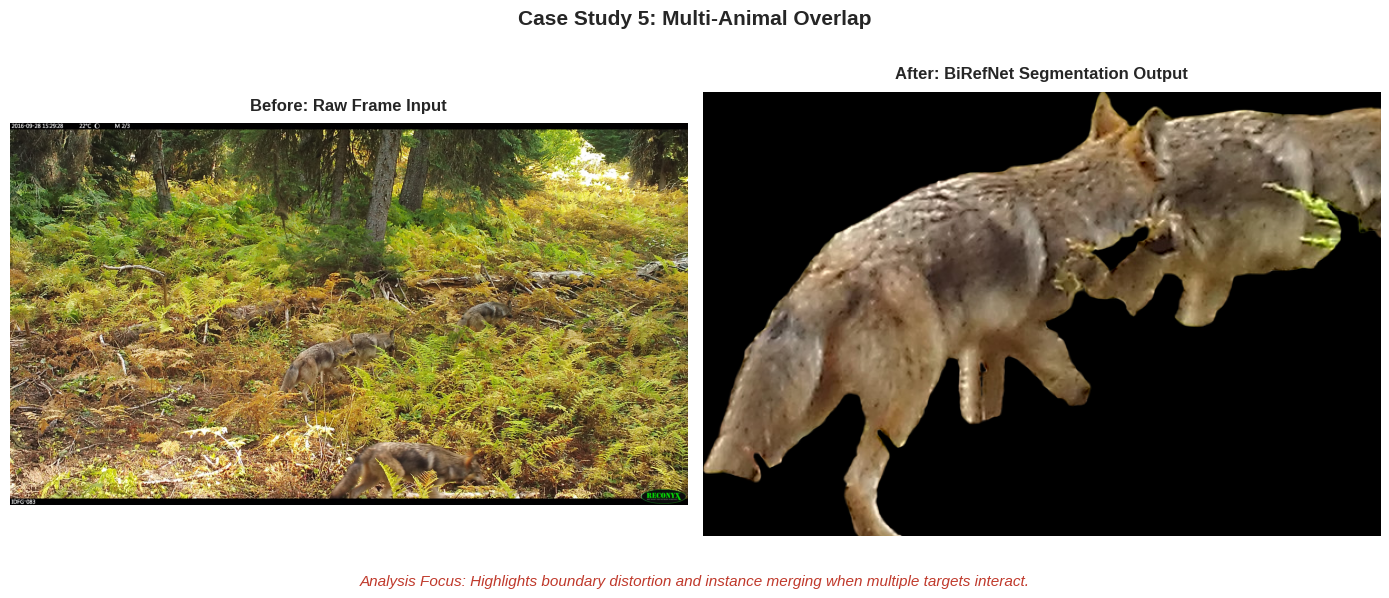

In [7]:
# Filter and execute failure analysis cases
for study in CASE_STUDIES:

    if study["type"] == "Failure":
        
        plot_case_study(study)